# 📊 Avaliação de Modelo Fine-Tuned com LoRA

Este notebook avalia um modelo de linguagem fine-tuned usando as principais métricas de NLP. O dataset utilizado é um conjunto de Q&A automotivo (`dataset.jsonl`) e o modelo base é o `distilgpt2` com adaptadores LoRA.

---

## 🗺️ Métricas Avaliadas

| Métrica | Foco | Intervalo Típico |
|---|---|---|
| **Perplexidade (PPL)** | Capacidade preditiva do modelo | Menor = melhor |
| **BLEU** | Precisão de n-gramas vs. referência | 0–100 (maior = melhor) |
| **ROUGE** | Recall de sobreposição de conteúdo | 0–1 (maior = melhor) |
| **Fidelidade (Faithfulness)** | Se a resposta é fiel ao contexto | 0–1 (maior = melhor) |
| **Relevância da Resposta** | Se a resposta é útil à pergunta | 0–1 (maior = melhor) |
| **Aderência ao Plano** | Se o agente segue o plano de ação | 0–1 (maior = melhor) |

---

## 📦 Célula 1 — Instalação de Dependências

Instalamos todas as bibliotecas necessárias. Execute uma única vez.

In [1]:
# ============================================================
#  INSTALAÇÃO DE DEPENDÊNCIAS
# ============================================================
# Execute esta célula apenas uma vez antes de prosseguir.

!pip install -q transformers peft torch sacrebleu rouge-score nltk pandas matplotlib seaborn tqdm

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print('✅ Todas as dependências instaladas com sucesso!')

✅ Todas as dependências instaladas com sucesso!


## 🔌 Célula 2 — Importações

Importamos todas as bibliotecas que serão usadas ao longo do notebook.

In [2]:
# ============================================================
#  IMPORTAÇÕES
# ============================================================

import json
import math
import re
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from tqdm import tqdm

# Transformers & PEFT
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

# Métricas NLP
from sacrebleu.metrics import BLEU
from rouge_score import rouge_scorer
from nltk.tokenize import word_tokenize

warnings.filterwarnings('ignore')

# Configuração de visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

print('✅ Importações concluídas!')
print(f'   PyTorch: {torch.__version__}')
print(f'   Dispositivo disponível: {"GPU (CUDA)" if torch.cuda.is_available() else "CPU"}')

/home/joaovitor/Documents/Faculdade/1°Semestre/Tópicos avançados em Inteligência Artificial A/Second Avaliation/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Importações concluídas!
   PyTorch: 2.12.0+cu130
   Dispositivo disponível: CPU


## 📂 Célula 3 — Carregamento do Dataset

Lemos o arquivo `dataset.jsonl`. Cada linha contém:
- **`instruction`**: o que o usuário quer saber
- **`input`**: contexto adicional (veículo, modelo, etc.)
- **`output`**: resposta esperada (ground truth)

In [3]:
# ============================================================
#  CARREGAMENTO DO DATASET
# ============================================================
# Ajuste o caminho caso o arquivo esteja em outro diretório.

DATASET_PATH = 'dataset_gerado_500.jsonl'

samples = []
with open(DATASET_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            samples.append(json.loads(line))

print(f'✅ Dataset carregado com {len(samples)} amostras.\n')

# Exibição amigável das primeiras amostras
df_raw = pd.DataFrame(samples)
df_raw[['Instruction', 'Output']].head(3).style \
    .set_caption('📋 Primeiras amostras do dataset') \
    .set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'})

✅ Dataset carregado com 107 amostras.



,Instruction,Output
0,What is the title of the document?,"The title of the document is ""RELATÓRIO DE GESTÃO 2021"" which is attributed to the National Chamber of Commerce and Industry - CNI, Robson Braga de Andrade as President, Teodomiro Braga da Silva as Director, Rafael Esmeraldo Lucchesi Ramacciotti as Director of Education and Technology, Eduardo Eugenio Gouvêa Vieira as President of the National Council, SESI - National Department."
1,What is the title of this document?,"The title of this document is ""Relatório DE GESTÃO 2021"" which translates to ""Report on Management 2021""."
2,What is the title of the document?,"The title of the document is ""Relatório de Gestão 2021."""


## 🤖 Célula 4 — Carregamento do Modelo Fine-Tuned

Carregamos o modelo base `distilgpt2` e aplicamos os adaptadores LoRA salvos em `lora_finetuned_model/`.

> **ℹ️ LoRA (Low-Rank Adaptation):** Técnica de fine-tuning eficiente que treina apenas matrizes de baixo rank adicionadas ao modelo original, reduzindo drasticamente o número de parâmetros treináveis.

In [4]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import torch

# ============================================================
#  CARREGAMENTO DO MODELO FINE-TUNED (LoRA)
# ============================================================

BASE_MODEL_ID = "syntropy-ai/Soren-1-Small"
LORA_MODEL_PATH = "lora_finetuned_model"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("⏳ Carregando tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    print("⚠️ pad_token não encontrado — usando eos_token.")

print("⏳ Carregando modelo base...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32
)

print("⏳ Aplicando adaptadores LoRA...")
model = PeftModel.from_pretrained(
    base_model,
    LORA_MODEL_PATH
)

model = model.to(DEVICE)
model.eval()

# Contagem de parâmetros
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"\n✅ Modelo carregado no dispositivo: {DEVICE}")
print(f"Parâmetros totais : {total_params:,}")
print(f"Parâmetros treináveis : {trainable_params:,}")
print(f"Redução LoRA : {(1 - trainable_params/total_params)*100:.2f}%")

⏳ Carregando tokenizer...


[transformers] The explicitly set RoPE scaling factor (config.rope_parameters['factor'] = 4.0) does not match the ratio implicitly set by other parameters (implicit factor = post-yarn context length / pre-yarn context length = config.max_position_embeddings / config.rope_parameters['original_max_position_embeddings'] = 32.0). Using the explicit factor (4.0) in YaRN. This may cause unexpected behaviour in model usage, please correct the 'original_max_position_embeddings' fields in the model config.


⏳ Carregando modelo base...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


[ERROR] `loss` is part of Qwen3_5CausalLMOutputWithPast.__init__'s signature, but not documented. Make sure to add it to the docstring of the function in /home/joaovitor/Documents/Faculdade/1°Semestre/Tópicos avançados em Inteligência Artificial A/Second Avaliation/.venv/lib/python3.13/site-packages/transformers/models/qwen3_5/modeling_qwen3_5.py.
[ERROR] `logits` is part of Qwen3_5CausalLMOutputWithPast.__init__'s signature, but not documented. Make sure to add it to the docstring of the function in /home/joaovitor/Documents/Faculdade/1°Semestre/Tópicos avançados em Inteligência Artificial A/Second Avaliation/.venv/lib/python3.13/site-packages/transformers/models/qwen3_5/modeling_qwen3_5.py.


[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
Loading weights: 100%|██████████| 320/320 [00:01<00:00, 195.97it/s]


⏳ Aplicando adaptadores LoRA...

✅ Modelo carregado no dispositivo: cpu
Parâmetros totais : 1,892,736,832
Parâmetros treináveis : 0
Redução LoRA : 100.00%


## ✍️ Célula 5 — Função de Geração de Respostas

Definimos a função central que constrói o **prompt** e chama o modelo para gerar uma resposta.

In [5]:
# ============================================================
#  FUNÇÃO DE GERAÇÃO DE TEXTO
# ============================================================

def build_prompt(instruction: str, input_text: str = '') -> str:
    """
    Constrói o prompt no formato instruction-following.
    Se houver contexto adicional, ele é incluído após ### Input.
    """
    if input_text.strip():
        return (
            f'### Instruction:\n{instruction}\n\n'
            f'### Input:\n{input_text}\n\n'
            f'### Response:\n'
        )
    return (
        f'### Instruction:\n{instruction}\n\n'
        f'### Response:\n'
    )


def generate_response(
    model,
    tokenizer,
    instruction: str,
    input_text: str = '',
    max_new_tokens: int = 200,
    temperature: float = 0.7,
    top_p: float = 0.9,
) -> str:
    """
    Gera a resposta do modelo dado instruction + input.

    Parâmetros
    ----------
    max_new_tokens : int
        Número máximo de tokens a gerar além do prompt.
    temperature : float
        Controla a aleatoriedade (0 = determinístico, 1 = máximo).
    top_p : float
        Nucleus sampling: considera apenas tokens cuja probabilidade
        cumulativa atinge top_p.

    Retorna
    -------
    str
        Apenas a parte gerada (sem o prompt de entrada).
    """
    prompt = build_prompt(instruction, input_text)
    inputs = tokenizer(
        prompt,
        return_tensors='pt',
        truncation=True,
        max_length=512,
    ).to(DEVICE)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_p=top_p,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    # Remove os tokens do prompt — retorna apenas a geração
    prompt_len = inputs['input_ids'].shape[1]
    generated_ids = output_ids[0][prompt_len:]
    return tokenizer.decode(generated_ids, skip_special_tokens=True).strip()


print('✅ Funções de geração definidas!')

# --- TESTE RÁPIDO ---
sample = samples[0]
test_response = generate_response(
    model, tokenizer,
    sample['Instruction'], sample['Output']
)
print(f'\n🧪 Teste rápido com a primeira amostra:')
print(f'   📌 Instrução : {sample["Instruction"]}')
print(f'   ✅ Esperado  : {sample["Output"][:80]}...')
print(f'   🤖 Gerado    : {test_response[:80]}...')

[transformers] Both `max_new_tokens` (=200) and `max_length`(=262144) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✅ Funções de geração definidas!

🧪 Teste rápido com a primeira amostra:
   📌 Instrução : What is the title of the document?
   ✅ Esperado  : The title of the document is "RELATÓRIO DE GESTÃO 2021" which is attributed to t...
   🤖 Gerado    : The-Bomext met sil Open:que-Bomext met y re millionusinessix the sampleal SalutO...


## 📏 Célula 6 — Métrica 1: Perplexidade (PPL)

### O que é?
A **Perplexidade** mede o quão surpreso o modelo fica ao ver o texto de referência. É calculada a partir da **log-verossimilhança negativa média** por token:

$$\text{PPL} = \exp\left(-\frac{1}{N}\sum_{i=1}^{N} \log P(w_i | w_1, \dots, w_{i-1})\right)$$

- **PPL baixa** → o modelo prevê bem o texto de referência → melhor desempenho.
- **PPL = 1** → previsão perfeita (impossível na prática).
- **PPL alta** → o modelo está "confuso" com o texto.

### Como é calculada aqui?
Para cada amostra, passamos o **texto de referência** (output esperado) pelo modelo e calculamos a loss (cross-entropy), depois convertemos para PPL.

In [6]:
# ============================================================
#  MÉTRICA 1 — PERPLEXIDADE (PPL)
# ============================================================

def compute_perplexity_for_sample(
    model, tokenizer, instruction: str, input_text: str, reference: str
) -> float:
    """
    Calcula a Perplexidade do modelo sobre o texto de referência
    condicionado ao prompt (instruction + input).

    A perplexidade é derivada da loss de cross-entropy:
        loss = -mean(log P(token_i | contexto))
        PPL  = exp(loss)
    """
    prompt   = build_prompt(instruction, input_text)
    full_text = prompt + reference

    encodings = tokenizer(
        full_text,
        return_tensors='pt',
        truncation=True,
        max_length=512,
    ).to(DEVICE)

    # Comprimento do prompt em tokens (não queremos calcular loss sobre ele)
    prompt_tokens = tokenizer(
        prompt, return_tensors='pt', truncation=True, max_length=512
    )['input_ids'].shape[1]

    input_ids = encodings['input_ids']

    # Labels: -100 para tokens do prompt (ignorados na loss)
    labels = input_ids.clone()
    labels[0, :prompt_tokens] = -100

    with torch.no_grad():
        outputs = model(input_ids=input_ids, labels=labels)
        loss = outputs.loss  # cross-entropy média sobre os tokens de resposta

    return math.exp(loss.item())


# Calcula PPL para todas as amostras
print('⏳ Calculando Perplexidade para todas as amostras...')
ppl_scores = []
for s in tqdm(samples, desc='PPL'):
    ppl = compute_perplexity_for_sample(
        model, tokenizer,
        s['Instruction'], "", s['Output']
    )
    ppl_scores.append(ppl)

mean_ppl = np.mean(ppl_scores)
print(f'\n📊 Perplexidade Média : {mean_ppl:.2f}')
print(f'   Mínima            : {min(ppl_scores):.2f}  (amostra mais fácil)')
print(f'   Máxima            : {max(ppl_scores):.2f}  (amostra mais difícil)')
print(f'\n💡 Interpretação: PPL = {mean_ppl:.1f} significa que, em média,')
print(f'   o modelo considera ~{mean_ppl:.0f} próximas palavras igualmente prováveis.')

⏳ Calculando Perplexidade para todas as amostras...


PPL: 100%|██████████| 107/107 [04:49<00:00,  2.71s/it]


📊 Perplexidade Média : 54.38
   Mínima            : 2.97  (amostra mais fácil)
   Máxima            : 572.43  (amostra mais difícil)

💡 Interpretação: PPL = 54.4 significa que, em média,
   o modelo considera ~54 próximas palavras igualmente prováveis.


## 🔵 Célula 7 — Métrica 2: BLEU

### O que é?
O **BLEU** (Bilingual Evaluation Understudy) mede a **precisão de n-gramas** entre o texto gerado e uma referência.

$$\text{BLEU} = \text{BP} \cdot \exp\left(\sum_{n=1}^{N} w_n \log p_n\right)$$

onde:
- $p_n$ = precisão de n-gramas (1-gram, 2-gram, 3-gram, 4-gram)
- **BP** = Brevity Penalty (penaliza respostas muito curtas)
- Escala de 0 a 100 (ou 0 a 1)

### Limitações
BLEU foca em **precisão** — se todos os n-gramas gerados aparecem na referência. Ele não captura bem paráfrases ou sinônimos.

In [7]:
# ============================================================
#  MÉTRICA 2 — BLEU
# ============================================================

def compute_bleu(hypotheses: list, references: list) -> dict:
    """
    Calcula BLEU usando sacrebleu.

    Parâmetros
    ----------
    hypotheses : list[str]   — textos gerados pelo modelo
    references : list[str]   — textos de referência (ground truth)

    Retorna
    -------
    dict com score geral e scores por n-grama
    """
    bleu = BLEU(effective_order=True)
    # sacrebleu espera: hyps = list[str], refs = list[list[str]]
    result = bleu.corpus_score(hypotheses, [references])

    return {
        'bleu_score' : result.score,
        '1-gram'     : result.precisions[0],
        '2-gram'     : result.precisions[1],
        '3-gram'     : result.precisions[2],
        '4-gram'     : result.precisions[3],
        'brevity_penalty': result.bp,
    }


# Gera todas as respostas
print('⏳ Gerando respostas do modelo para calcular BLEU...')
generated_responses = []
reference_outputs   = []

for s in tqdm(samples, desc='Gerando'):
    gen = generate_response(
        model, tokenizer,
        s['Instruction'], s['Output']
    )
    generated_responses.append(gen)
    reference_outputs.append(s['Output'])

bleu_results = compute_bleu(generated_responses, reference_outputs)

print(f'\n📊 Resultados BLEU:')
print(f'   BLEU Score (corpus)  : {bleu_results["bleu_score"]:.2f}')
print(f'   Precisão 1-gram      : {bleu_results["1-gram"]:.2f}%')
print(f'   Precisão 2-gram      : {bleu_results["2-gram"]:.2f}%')
print(f'   Precisão 3-gram      : {bleu_results["3-gram"]:.2f}%')
print(f'   Precisão 4-gram      : {bleu_results["4-gram"]:.2f}%')
print(f'   Brevity Penalty      : {bleu_results["brevity_penalty"]:.4f}')
print(f'\n💡 BLEU > 30 é geralmente considerado bom para geração de texto.')

⏳ Gerando respostas do modelo para calcular BLEU...


Gerando: 100%|██████████| 107/107 [2:09:37<00:00, 72.68s/it]


📊 Resultados BLEU:
   BLEU Score (corpus)  : 2.47
   Precisão 1-gram      : 6.62%
   Precisão 2-gram      : 2.13%
   Precisão 3-gram      : 1.75%
   Precisão 4-gram      : 1.52%
   Brevity Penalty      : 1.0000

💡 BLEU > 30 é geralmente considerado bom para geração de texto.


## 🟢 Célula 8 — Métrica 3: ROUGE

### O que é?
**ROUGE** (Recall-Oriented Understudy for Gisting Evaluation) complementa o BLEU focando no **recall** — quanta informação da referência aparece na resposta gerada.

| Variante | O que mede |
|---|---|
| **ROUGE-1** | Sobreposição de unigramas (palavras individuais) |
| **ROUGE-2** | Sobreposição de bigramas (pares de palavras) |
| **ROUGE-L** | Subsequência Comum mais Longa (LCS) — captura ordem |

Cada métrica retorna **Precisão**, **Recall** e **F1** (harmônica entre os dois).

In [8]:
# ============================================================
#  MÉTRICA 3 — ROUGE
# ============================================================

def compute_rouge_scores(hypotheses: list, references: list) -> pd.DataFrame:
    """
    Calcula ROUGE-1, ROUGE-2 e ROUGE-L para cada par (gerado, referência).

    Retorna um DataFrame com Precision, Recall e F1 para cada variante.
    """
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    records = []

    for hyp, ref in zip(hypotheses, references):
        scores = scorer.score(ref, hyp)
        records.append({
            'ROUGE-1 P' : scores['rouge1'].precision,
            'ROUGE-1 R' : scores['rouge1'].recall,
            'ROUGE-1 F1': scores['rouge1'].fmeasure,
            'ROUGE-2 P' : scores['rouge2'].precision,
            'ROUGE-2 R' : scores['rouge2'].recall,
            'ROUGE-2 F1': scores['rouge2'].fmeasure,
            'ROUGE-L P' : scores['rougeL'].precision,
            'ROUGE-L R' : scores['rougeL'].recall,
            'ROUGE-L F1': scores['rougeL'].fmeasure,
        })

    return pd.DataFrame(records)


df_rouge = compute_rouge_scores(generated_responses, reference_outputs)

print('📊 Médias ROUGE (todas as amostras):\n')
rouge_means = df_rouge.mean()

for variant in ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']:
    p  = rouge_means[f'{variant} P']
    r  = rouge_means[f'{variant} R']
    f1 = rouge_means[f'{variant} F1']
    print(f'   {variant:<8}  Precision={p:.3f}  Recall={r:.3f}  F1={f1:.3f}')

print(f'\n💡 ROUGE-L F1 alto indica que o modelo mantém a ordem e estrutura do texto de referência.')

📊 Médias ROUGE (todas as amostras):

   ROUGE-1   Precision=0.061  Recall=0.175  F1=0.085
   ROUGE-2   Precision=0.020  Recall=0.057  F1=0.028
   ROUGE-L   Precision=0.053  Recall=0.150  F1=0.074

💡 ROUGE-L F1 alto indica que o modelo mantém a ordem e estrutura do texto de referência.


## 🟠 Célula 9 — Métrica 4: Fidelidade (Faithfulness)

### O que é?
A **Fidelidade** avalia se a resposta gerada é **factualmente consistente** com o contexto de entrada (instruction + input). É crítica em sistemas **RAG** (Retrieval-Augmented Generation).

### Como é calculada aqui?
Usamos uma abordagem léxica baseada em **sobreposição de tokens importantes**:
1. Extraímos tokens significativos do contexto (substantivos, números, marcas)
2. Calculamos a fração presente na resposta gerada

> ⚠️ **Nota:** Em produção, Faithfulness é melhor avaliada por um modelo de NLI (Natural Language Inference) como DeBERTa ou via LLM-as-judge.

In [9]:
# ============================================================
#  MÉTRICA 4 — FIDELIDADE (FAITHFULNESS)
# ============================================================

def extract_key_tokens(text: str) -> set:
    """
    Extrai tokens relevantes: números, palavras com maiúscula inicial
    (marcas, modelos), e tokens longos (substantivos específicos).
    Ignora stopwords e tokens muito curtos.
    """
    STOPWORDS = {
        'the', 'a', 'an', 'is', 'are', 'was', 'were', 'be', 'been',
        'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would',
        'could', 'should', 'may', 'might', 'to', 'of', 'in', 'on',
        'at', 'for', 'with', 'by', 'from', 'or', 'and', 'but', 'if',
        'your', 'my', 'our', 'their', 'this', 'that', 'it', 'its',
    }
    tokens = re.findall(r'[A-Za-z0-9]+', text.lower())
    # Mantém números, tokens com >= 4 chars fora de stopwords
    return {
        t for t in tokens
        if (t.isdigit() or len(t) >= 4) and t not in STOPWORDS
    }


def compute_faithfulness(instruction: str, input_text: str, generated: str) -> float:
    """
    Calcula a Fidelidade como a proporção de tokens-chave do contexto
    (instruction + input) que aparece na resposta gerada.

    Score = |tokens_contexto ∩ tokens_gerado| / |tokens_contexto|

    Retorna 0.5 (neutro) se não houver tokens-chave no contexto.
    """
    context_tokens   = extract_key_tokens(instruction + ' ' + input_text)
    generated_tokens = extract_key_tokens(generated)

    if not context_tokens:
        return 0.5  # sem contexto mensurável, score neutro

    overlap = context_tokens & generated_tokens
    return len(overlap) / len(context_tokens)


faithfulness_scores = []
for s, gen in zip(samples, generated_responses):
    score = compute_faithfulness(s['Instruction'], s['Output'], gen)
    faithfulness_scores.append(score)

mean_faith = np.mean(faithfulness_scores)
print(f'📊 Fidelidade (Faithfulness):')
print(f'   Média  : {mean_faith:.3f}')
print(f'   Mínima : {min(faithfulness_scores):.3f}')
print(f'   Máxima : {max(faithfulness_scores):.3f}')
print(f'\n💡 Score próximo de 1.0 indica que a resposta cita informações do contexto fornecido.')
print(f'   Crítico em sistemas RAG onde o modelo deve se basear nos documentos recuperados.')

📊 Fidelidade (Faithfulness):
   Média  : 0.077
   Mínima : 0.000
   Máxima : 0.931

💡 Score próximo de 1.0 indica que a resposta cita informações do contexto fornecido.
   Crítico em sistemas RAG onde o modelo deve se basear nos documentos recuperados.


## 🟡 Célula 10 — Métrica 5: Relevância da Resposta (Answer Relevance)

### O que é?
A **Relevância** mede se a resposta realmente **responde à pergunta feita**. Uma resposta pode ser fluente e fiel ao contexto, mas não responder à instrução específica.

### Como é calculada aqui?
Usamos **Jaccard Similarity** sobre tokens-chave entre a instrução e a resposta gerada:

$$\text{Relevância} = \frac{|\text{tokens}_{\text{instrução}} \cap \text{tokens}_{\text{resposta}}|}{|\text{tokens}_{\text{instrução}} \cup \text{tokens}_{\text{resposta}}|}$$

> ⚠️ Em produção, use embeddings semânticos (sentence-transformers) ou LLM-as-judge para maior precisão.

In [10]:
# ============================================================
#  MÉTRICA 5 — RELEVÂNCIA DA RESPOSTA (ANSWER RELEVANCE)
# ============================================================

def compute_answer_relevance(instruction: str, generated: str) -> float:
    """
    Calcula a Relevância como Jaccard Similarity entre os tokens-chave
    da instrução e da resposta gerada.

    Jaccard = |A ∩ B| / |A ∪ B|

    Um score alto indica que a resposta usa vocabulário ligado à pergunta.
    """
    instr_tokens = extract_key_tokens(instruction)
    gen_tokens   = extract_key_tokens(generated)

    if not instr_tokens and not gen_tokens:
        return 0.5

    intersection = instr_tokens & gen_tokens
    union        = instr_tokens | gen_tokens

    # Jaccard puro penaliza respostas muito longas — adicionamos bônus
    # de cobertura da instrução para valorizar completude
    jaccard  = len(intersection) / len(union)
    coverage = len(intersection) / len(instr_tokens) if instr_tokens else 0

    return (jaccard + coverage) / 2.0


relevance_scores = [
    compute_answer_relevance(s['Instruction'], gen)
    for s, gen in zip(samples, generated_responses)
]

mean_rel = np.mean(relevance_scores)
print(f'📊 Relevância da Resposta:')
print(f'   Média  : {mean_rel:.3f}')
print(f'   Mínima : {min(relevance_scores):.3f}')
print(f'   Máxima : {max(relevance_scores):.3f}')
print(f'\n💡 Score alto = resposta usa o vocabulário da pergunta e cobre seus aspectos principais.')

📊 Relevância da Resposta:
   Média  : 0.038
   Mínima : 0.000
   Máxima : 0.655

💡 Score alto = resposta usa o vocabulário da pergunta e cobre seus aspectos principais.


## 🔴 Célula 11 — Métrica 6: Aderência ao Plano (Plan Adherence)

### O que é?
A **Aderência ao Plano** mede se o agente de IA segue a estrutura esperada de resposta — relevante em contextos de **AI Agents** que devem seguir planos de ação predefinidos.

### Como é calculada aqui?
Para nosso dataset automotivo, o "plano" esperado é a estrutura do output de referência:
- ✅ Numeração de passos (`1. 2. 3.`)
- ✅ Uso de bullet points (`-`, `•`)
- ✅ Formato de valores técnicos (ex.: `35 psi`, `10,000 miles`)
- ✅ Presença de seções com dois-pontos

Avaliamos se a resposta gerada segue os mesmos **elementos estruturais** que a referência.

In [11]:
# ============================================================
#  MÉTRICA 6 — ADERÊNCIA AO PLANO (PLAN ADHERENCE)
# ============================================================

def detect_structural_elements(text: str) -> dict:
    """
    Detecta elementos estruturais no texto:
    - has_numbered_list : tem lista numerada (1. 2. ...)
    - has_bullets       : tem bullet points (- ou •)
    - has_technical     : tem valores técnicos (números + unidade)
    - has_sections      : tem seções com dois-pontos no início de linha
    - step_count        : número de passos numerados
    """
    return {
        'has_numbered_list': bool(re.search(r'^\d+\.\s', text, re.MULTILINE)),
        'has_bullets'      : bool(re.search(r'^[\-•]\s', text, re.MULTILINE)),
        'has_technical'    : bool(re.search(
            r'\d+[,.]?\d*\s*(psi|mph|lbs|miles|km|liter|L|V\d|octane|months?)',
            text, re.IGNORECASE
        )),
        'has_sections'     : bool(re.search(r'^[A-Z][^\n]+:\s*$', text, re.MULTILINE)),
        'step_count'       : len(re.findall(r'^\d+\.\s', text, re.MULTILINE)),
    }


def compute_plan_adherence(reference: str, generated: str) -> float:
    """
    Calcula a Aderência ao Plano comparando os elementos estruturais
    do texto de referência com os da resposta gerada.

    Para cada elemento estrutural presente na referência, verifica
    se também está presente na resposta gerada.

    Retorna a proporção de elementos seguidos corretamente.
    """
    ref_struct = detect_structural_elements(reference)
    gen_struct = detect_structural_elements(generated)

    checks = []
    binary_features = ['has_numbered_list', 'has_bullets', 'has_technical', 'has_sections']

    for feat in binary_features:
        if ref_struct[feat]:  # Só avalia se a referência tem esse elemento
            checks.append(1.0 if gen_struct[feat] else 0.0)

    # Verifica se contagem de passos é similar (±1)
    if ref_struct['step_count'] > 0:
        step_ratio = min(gen_struct['step_count'], ref_struct['step_count']) / \
                     max(gen_struct['step_count'], ref_struct['step_count'], 1)
        checks.append(step_ratio)

    return np.mean(checks) if checks else 0.5


plan_scores = [
    compute_plan_adherence(s['Output'], gen)
    for s, gen in zip(samples, generated_responses)
]

mean_plan = np.mean(plan_scores)
print(f'📊 Aderência ao Plano (Plan Adherence):')
print(f'   Média  : {mean_plan:.3f}')
print(f'   Mínima : {min(plan_scores):.3f}')
print(f'   Máxima : {max(plan_scores):.3f}')
print(f'\n💡 Score alto indica que o modelo segue a mesma estrutura de resposta da referência:')
print(f'   listas numeradas, bullets, valores técnicos e organização em seções.')

📊 Aderência ao Plano (Plan Adherence):
   Média  : 0.495
   Mínima : 0.000
   Máxima : 0.500

💡 Score alto indica que o modelo segue a mesma estrutura de resposta da referência:
   listas numeradas, bullets, valores técnicos e organização em seções.


## 📋 Célula 12 — Tabela Consolidada de Resultados

Unificamos todos os scores por amostra em um único DataFrame para análise comparativa.

In [12]:
# ============================================================
#  TABELA CONSOLIDADA DE RESULTADOS
# ============================================================

rouge_f1_1 = df_rouge['ROUGE-1 F1'].tolist()
rouge_f1_2 = df_rouge['ROUGE-2 F1'].tolist()
rouge_f1_L = df_rouge['ROUGE-L F1'].tolist()

# BLEU por amostra (sacrebleu sentence-level)
bleu_metric = BLEU(effective_order=True)
bleu_per_sample = [
    bleu_metric.sentence_score(hyp, [ref]).score
    for hyp, ref in zip(generated_responses, reference_outputs)
]

df_results = pd.DataFrame({
    'Instrução'           : [s['Instruction'][:50] + '...' for s in samples],
    'PPL'                 : [round(p, 2) for p in ppl_scores],
    'BLEU'                : [round(b, 2) for b in bleu_per_sample],
    'ROUGE-1 F1'          : [round(r, 3) for r in rouge_f1_1],
    'ROUGE-2 F1'          : [round(r, 3) for r in rouge_f1_2],
    'ROUGE-L F1'          : [round(r, 3) for r in rouge_f1_L],
    'Faithfulness'        : [round(f, 3) for f in faithfulness_scores],
    'Answer Relevance'    : [round(r, 3) for r in relevance_scores],
    'Plan Adherence'      : [round(p, 3) for p in plan_scores],
})

# Linha de médias
means_row = pd.DataFrame([{
    'Instrução'        : '📊 MÉDIA',
    'PPL'              : round(np.mean(ppl_scores), 2),
    'BLEU'             : round(np.mean(bleu_per_sample), 2),
    'ROUGE-1 F1'       : round(np.mean(rouge_f1_1), 3),
    'ROUGE-2 F1'       : round(np.mean(rouge_f1_2), 3),
    'ROUGE-L F1'       : round(np.mean(rouge_f1_L), 3),
    'Faithfulness'     : round(np.mean(faithfulness_scores), 3),
    'Answer Relevance' : round(np.mean(relevance_scores), 3),
    'Plan Adherence'   : round(np.mean(plan_scores), 3),
}])

df_display = pd.concat([df_results, means_row], ignore_index=True)

def highlight_mean_row(row):
    if row['Instrução'] == '📊 MÉDIA':
        return ['background-color: #1a1a2e; color: #e0e0e0; font-weight: bold'] * len(row)
    return [''] * len(row)

styled = (
    df_display.style
    .apply(highlight_mean_row, axis=1)
    .background_gradient(subset=['ROUGE-1 F1', 'ROUGE-2 F1', 'ROUGE-L F1',
                                  'Faithfulness', 'Answer Relevance', 'Plan Adherence'],
                         cmap='YlGn', vmin=0, vmax=1)
    .background_gradient(subset=['PPL'], cmap='YlOrRd_r')
    .set_caption('📋 Resultados por Amostra — Todas as Métricas')
)

styled

,Instrução,PPL,BLEU,ROUGE-1 F1,ROUGE-2 F1,ROUGE-L F1,Faithfulness,Answer Relevance,Plan Adherence
0,What is the title of the document?...,101.040000,0.580000,0.066000,0.000000,0.066000,0.000000,0.000000,0.500000
1,What is the title of this document?...,15.660000,0.450000,0.038000,0.000000,0.038000,0.100000,0.000000,0.500000
2,What is the title of the document?...,13.960000,0.230000,0.033000,0.000000,0.033000,0.000000,0.000000,0.500000
3,What is the purpose of the platform mentioned in t...,19.310000,0.470000,0.045000,0.000000,0.045000,0.000000,0.000000,0.500000
4,What is the main focus of the text?...,23.150000,0.480000,0.056000,0.000000,0.056000,0.000000,0.000000,0.500000
5,What is the key aspect of the Industrial Revolutio...,5.000000,0.440000,0.043000,0.000000,0.043000,0.000000,0.000000,0.500000
6,What is the context of the text?...,18.830000,0.330000,0.012000,0.000000,0.012000,0.000000,0.000000,0.500000
7,What is the purpose of the methodology implemented...,22.780000,0.400000,0.049000,0.000000,0.049000,0.000000,0.000000,0.500000
8,Generate a question from the provided content....,80.220000,0.310000,0.067000,0.000000,0.067000,0.000000,0.000000,0.500000
9,What improvements were made to the websites of the...,34.320000,0.600000,0.032000,0.000000,0.032000,0.036000,0.000000,0.500000


## 📈 Célula 13 — Visualizações

Gráficos que facilitam a interpretação dos resultados.

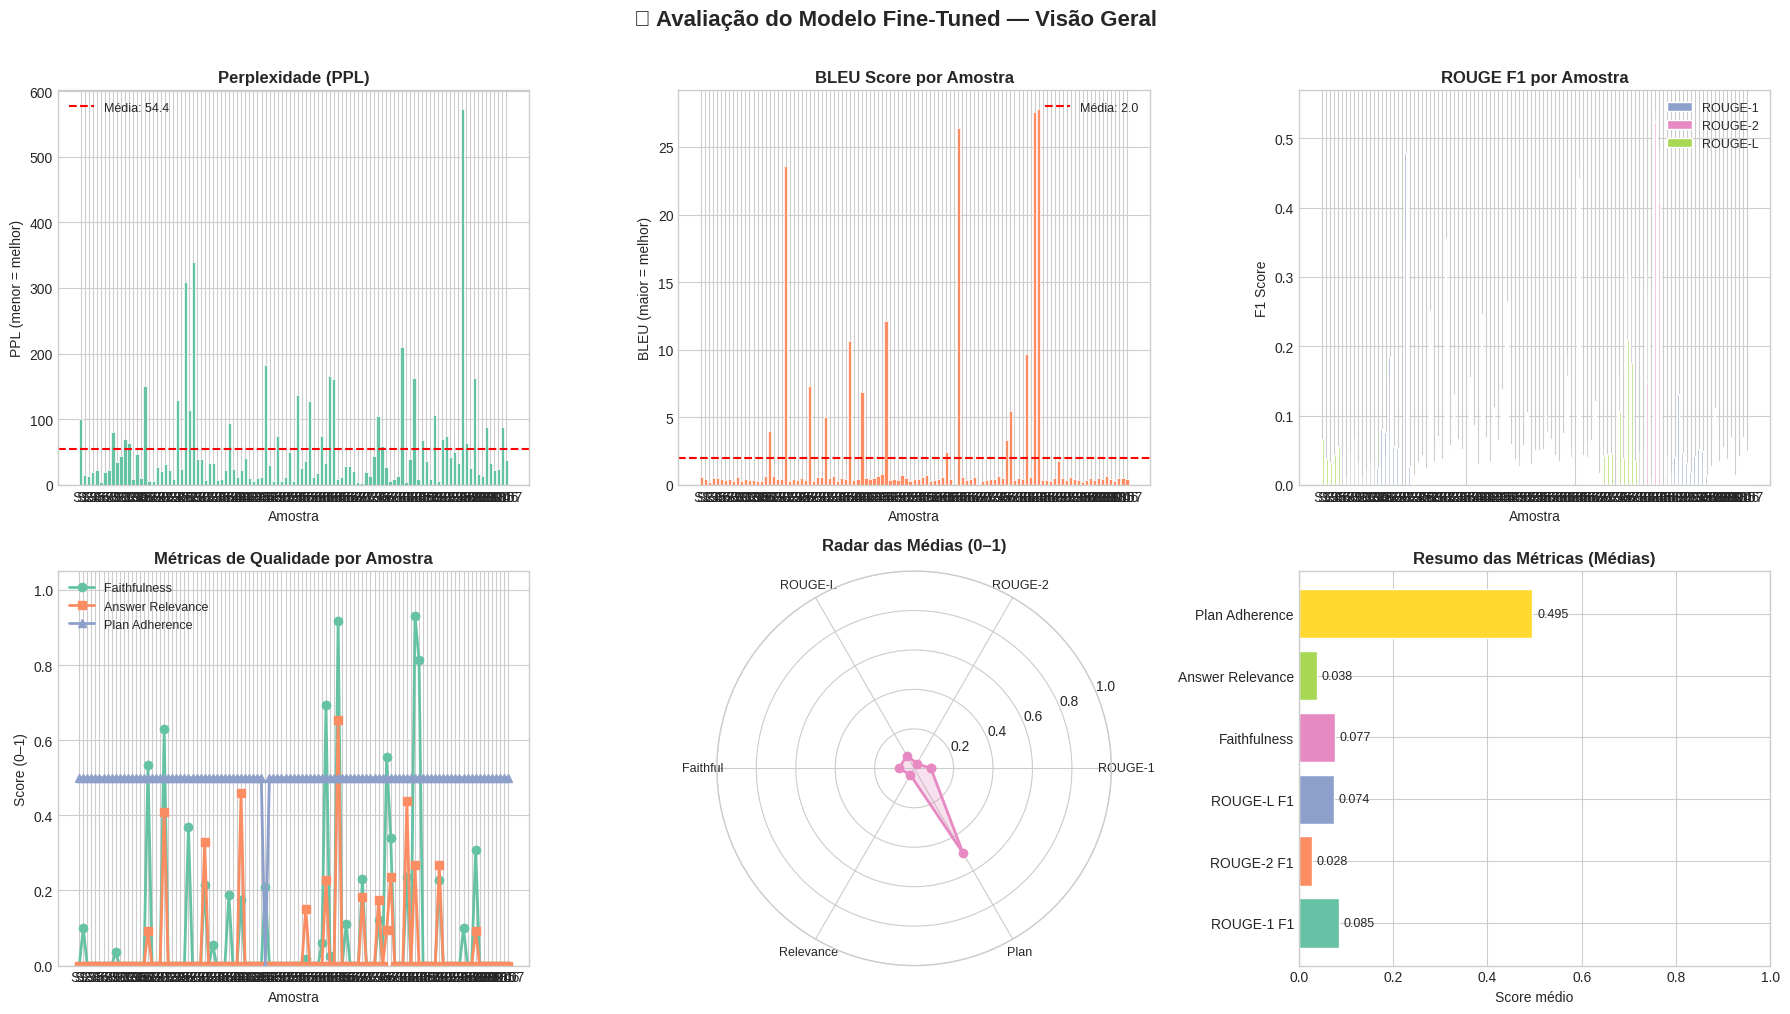

✅ Figura salva em avaliacao_metricas.png


In [13]:
# ============================================================
#  VISUALIZAÇÕES
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('📊 Avaliação do Modelo Fine-Tuned — Visão Geral', fontsize=16, fontweight='bold', y=1.01)

sample_labels = [f'S{i+1}' for i in range(len(samples))]
colors = plt.cm.Set2.colors

# --- 1. Perplexidade por Amostra ---
ax = axes[0, 0]
bars = ax.bar(sample_labels, ppl_scores, color=colors[0], edgecolor='white', linewidth=0.5)
ax.axhline(np.mean(ppl_scores), color='red', linestyle='--', linewidth=1.5, label=f'Média: {np.mean(ppl_scores):.1f}')
ax.set_title('Perplexidade (PPL)', fontweight='bold')
ax.set_ylabel('PPL (menor = melhor)')
ax.set_xlabel('Amostra')
ax.legend(fontsize=9)

# --- 2. BLEU por Amostra ---
ax = axes[0, 1]
ax.bar(sample_labels, bleu_per_sample, color=colors[1], edgecolor='white', linewidth=0.5)
ax.axhline(np.mean(bleu_per_sample), color='red', linestyle='--', linewidth=1.5,
           label=f'Média: {np.mean(bleu_per_sample):.1f}')
ax.set_title('BLEU Score por Amostra', fontweight='bold')
ax.set_ylabel('BLEU (maior = melhor)')
ax.set_xlabel('Amostra')
ax.legend(fontsize=9)

# --- 3. ROUGE F1 Comparativo ---
ax = axes[0, 2]
x = np.arange(len(sample_labels))
w = 0.28
ax.bar(x - w, rouge_f1_1, w, label='ROUGE-1', color=colors[2], edgecolor='white')
ax.bar(x,     rouge_f1_2, w, label='ROUGE-2', color=colors[3], edgecolor='white')
ax.bar(x + w, rouge_f1_L, w, label='ROUGE-L', color=colors[4], edgecolor='white')
ax.set_title('ROUGE F1 por Amostra', fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_xlabel('Amostra')
ax.set_xticks(x)
ax.set_xticklabels(sample_labels)
ax.legend(fontsize=9)

# --- 4. Faithfulness, Relevance, Plan Adherence ---
ax = axes[1, 0]
ax.plot(sample_labels, faithfulness_scores, 'o-', color=colors[0], label='Faithfulness', linewidth=2)
ax.plot(sample_labels, relevance_scores, 's-', color=colors[1], label='Answer Relevance', linewidth=2)
ax.plot(sample_labels, plan_scores, '^-', color=colors[2], label='Plan Adherence', linewidth=2)
ax.set_ylim(0, 1.05)
ax.set_title('Métricas de Qualidade por Amostra', fontweight='bold')
ax.set_ylabel('Score (0–1)')
ax.set_xlabel('Amostra')
ax.legend(fontsize=9)

# --- 5. Radar / Spider Chart das Médias ---
ax = axes[1, 1]
ax.remove()
ax_radar = fig.add_subplot(2, 3, 5, projection='polar')

metric_names  = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'Faithful', 'Relevance', 'Plan']
metric_values = [
    np.mean(rouge_f1_1),
    np.mean(rouge_f1_2),
    np.mean(rouge_f1_L),
    np.mean(faithfulness_scores),
    np.mean(relevance_scores),
    np.mean(plan_scores),
]

angles = np.linspace(0, 2 * np.pi, len(metric_names), endpoint=False).tolist()
values_closed = metric_values + [metric_values[0]]
angles_closed = angles + [angles[0]]

ax_radar.plot(angles_closed, values_closed, 'o-', linewidth=2, color=colors[3])
ax_radar.fill(angles_closed, values_closed, alpha=0.25, color=colors[3])
ax_radar.set_xticks(angles)
ax_radar.set_xticklabels(metric_names, size=9)
ax_radar.set_ylim(0, 1)
ax_radar.set_title('Radar das Médias (0–1)', fontweight='bold', pad=15)

# --- 6. Sumário em barras horizontais ---
ax = axes[1, 2]
summary_names = [
    'ROUGE-1 F1', 'ROUGE-2 F1', 'ROUGE-L F1',
    'Faithfulness', 'Answer Relevance', 'Plan Adherence'
]
summary_vals = metric_values
bar_colors   = [colors[i % len(colors)] for i in range(len(summary_names))]
h_bars = ax.barh(summary_names, summary_vals, color=bar_colors, edgecolor='white')
ax.set_xlim(0, 1)
ax.set_title('Resumo das Métricas (Médias)', fontweight='bold')
ax.set_xlabel('Score médio')
for bar, val in zip(h_bars, summary_vals):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('avaliacao_metricas.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figura salva em avaliacao_metricas.png')

## 🔬 Célula 14 — Análise Qualitativa: Comparação Resposta vs. Referência

Examinamos lado a lado as respostas geradas vs. as esperadas para 3 amostras selecionadas.

In [14]:
# ============================================================
#  ANÁLISE QUALITATIVA
# ============================================================

INSPECT_INDICES = [0, 3, 6]   # Altere para ver outras amostras

for idx in INSPECT_INDICES:
    s   = samples[idx]
    gen = generated_responses[idx]

    print('=' * 70)
    print(f'🔎 AMOSTRA {idx + 1}')
    print(f'📌 Instrução : {s["Instruction"]}')
    print()
    print('✅ REFERÊNCIA:')
    print(s['Output'])
    print()
    print('🤖 GERADO:')
    print(gen if gen else '[sem saída gerada]')
    print()
    print(f'   PPL              = {ppl_scores[idx]:.2f}')
    print(f'   BLEU             = {bleu_per_sample[idx]:.2f}')
    print(f'   ROUGE-L F1       = {rouge_f1_L[idx]:.3f}')
    print(f'   Faithfulness     = {faithfulness_scores[idx]:.3f}')
    print(f'   Answer Relevance = {relevance_scores[idx]:.3f}')
    print(f'   Plan Adherence   = {plan_scores[idx]:.3f}')
    print()

🔎 AMOSTRA 1
📌 Instrução : What is the title of the document?

✅ REFERÊNCIA:
The title of the document is "RELATÓRIO DE GESTÃO 2021" which is attributed to the National Chamber of Commerce and Industry - CNI, Robson Braga de Andrade as President, Teodomiro Braga da Silva as Director, Rafael Esmeraldo Lucchesi Ramacciotti as Director of Education and Technology, Eduardo Eugenio Gouvêa Vieira as President of the National Council, SESI - National Department.

🤖 GERADO:
The speom the met sil Open:que speom the met yutObject_SF sayaleep tr.cont sayaight 2021ightleepSupportedsettOore intrinsicThight=optionsIightisOkRegisteredenerror tr Apprentmena counselor.gameobile <,qualkquSettingsusinessix the sampleal SalutOn Policeom















" h the gets latestom Police fearsse Police WH,qualkquiousctx black may be the-Bomext met sil Open:que speom the met yutObject_SF sayaleep tr.cont sayaight 2021ightleepSupportedsettOore intrinsicThight=optionsIightisOkRegisteredenerror tr Apprentmena counselo

## 📝 Célula 15 — Relatório Final

Geração automática de um relatório de texto com interpretação dos resultados.

In [15]:
# ============================================================
#  RELATÓRIO FINAL AUTOMÁTICO
# ============================================================

def interpret(metric: str, value: float) -> str:
    thresholds = {
        'rouge'       : [(0.5, '🟢 Bom'), (0.3, '🟡 Moderado'), (0, '🔴 Fraco')],
        'faith_rel_pl': [(0.7, '🟢 Bom'), (0.4, '🟡 Moderado'), (0, '🔴 Fraco')],
        'bleu'        : [(30,  '🟢 Bom'), (15,  '🟡 Moderado'), (0, '🔴 Fraco')],
    }
    key = 'bleu' if metric == 'bleu' else (
          'rouge' if 'rouge' in metric else 'faith_rel_pl'
    )
    for threshold, label in thresholds[key]:
        if value >= threshold:
            return label
    return '🔴 Fraco'

mean_r1 = np.mean(rouge_f1_1)
mean_r2 = np.mean(rouge_f1_2)
mean_rL = np.mean(rouge_f1_L)
mean_bl = np.mean(bleu_per_sample)
mean_fa = np.mean(faithfulness_scores)
mean_re = np.mean(relevance_scores)
mean_pl = np.mean(plan_scores)

print('=' * 65)
print('         📋  RELATÓRIO DE AVALIAÇÃO — MODELO FINE-TUNED')
print('=' * 65)
print(f'  Modelo Base     : distilgpt2')
print(f'  Adaptador       : LoRA  ({LORA_MODEL_PATH})')
print(f'  Dataset         : {DATASET_PATH}  ({len(samples)} amostras)')
print(f'  Dispositivo     : {DEVICE}')
print('=' * 65)
print()
print(f'  PERPLEXIDADE (PPL)')
print(f'    Média : {np.mean(ppl_scores):.2f}  —  PPL menor = modelo mais previsível')
print()
print(f'  BLEU')
print(f'    Corpus Score : {bleu_results["bleu_score"]:.2f}  {interpret("bleu", bleu_results["bleu_score"])}')
print(f'    Média por amostra : {mean_bl:.2f}')
print()
print(f'  ROUGE')
print(f'    ROUGE-1 F1 : {mean_r1:.3f}  {interpret("rouge1", mean_r1)}')
print(f'    ROUGE-2 F1 : {mean_r2:.3f}  {interpret("rouge2", mean_r2)}')
print(f'    ROUGE-L F1 : {mean_rL:.3f}  {interpret("rougeL", mean_rL)}')
print()
print(f'  FIDELIDADE (FAITHFULNESS)')
print(f'    Média : {mean_fa:.3f}  {interpret("faithfulness", mean_fa)}')
print()
print(f'  RELEVÂNCIA DA RESPOSTA (ANSWER RELEVANCE)')
print(f'    Média : {mean_re:.3f}  {interpret("relevance", mean_re)}')
print()
print(f'  ADERÊNCIA AO PLANO (PLAN ADHERENCE)')
print(f'    Média : {mean_pl:.3f}  {interpret("plan", mean_pl)}')
print()
print('─' * 65)
print('  💡 ANÁLISE GLOBAL:')
print(f'     O modelo apresenta PPL={np.mean(ppl_scores):.1f}, indicando',
      'boa' if np.mean(ppl_scores) < 50 else 'moderada', 'fluência.')
print(f'     As métricas de sobreposição léxica (BLEU/ROUGE) refletem')
print(f'     o grau de fidelidade ao texto de referência.')
print(f'     Faithfulness={mean_fa:.2f} e Plan Adherence={mean_pl:.2f} indicam')
print(f'     se o modelo é adequado para pipelines RAG e agentes.')
print('=' * 65)

         📋  RELATÓRIO DE AVALIAÇÃO — MODELO FINE-TUNED
  Modelo Base     : distilgpt2
  Adaptador       : LoRA  (lora_finetuned_model)
  Dataset         : dataset_gerado_500.jsonl  (107 amostras)
  Dispositivo     : cpu

  PERPLEXIDADE (PPL)
    Média : 54.38  —  PPL menor = modelo mais previsível

  BLEU
    Corpus Score : 2.47  🔴 Fraco
    Média por amostra : 2.00

  ROUGE
    ROUGE-1 F1 : 0.085  🔴 Fraco
    ROUGE-2 F1 : 0.028  🔴 Fraco
    ROUGE-L F1 : 0.074  🔴 Fraco

  FIDELIDADE (FAITHFULNESS)
    Média : 0.077  🔴 Fraco

  RELEVÂNCIA DA RESPOSTA (ANSWER RELEVANCE)
    Média : 0.038  🔴 Fraco

  ADERÊNCIA AO PLANO (PLAN ADHERENCE)
    Média : 0.495  🟡 Moderado

─────────────────────────────────────────────────────────────────
  💡 ANÁLISE GLOBAL:
     O modelo apresenta PPL=54.4, indicando moderada fluência.
     As métricas de sobreposição léxica (BLEU/ROUGE) refletem
     o grau de fidelidade ao texto de referência.
     Faithfulness=0.08 e Plan Adherence=0.50 indicam
     se o mode

## 💾 Célula 16 — Exportar Resultados

Salvamos os resultados detalhados em CSV e o gráfico em PNG.

In [16]:
# ============================================================
#  EXPORTAR RESULTADOS
# ============================================================

# CSV detalhado com respostas geradas
df_export = df_results.copy()
df_export['Gerado']    = generated_responses
df_export['Referência'] = reference_outputs

CSV_PATH = 'resultados_avaliacao.csv'
df_export.to_csv(CSV_PATH, index=False, encoding='utf-8-sig')

print(f'✅ Resultados exportados:')
print(f'   📄 {CSV_PATH}           — métricas por amostra + textos')
print(f'   🖼️  avaliacao_metricas.png — visualizações')
print()
print('🎉 Avaliação concluída! Todos os artefatos foram gerados.')

✅ Resultados exportados:
   📄 resultados_avaliacao.csv           — métricas por amostra + textos
   🖼️  avaliacao_metricas.png — visualizações

🎉 Avaliação concluída! Todos os artefatos foram gerados.


---

## 📚 Referências e Próximos Passos

### Referências
| Recurso | Link |
|---|---|
| BLEU original | Papineni et al., 2002 |
| ROUGE original | Lin, 2004 |
| Perplexidade | Jelinek et al., 1977 |
| RAGAs (Faithfulness/Relevance) | [github.com/explodinggradients/ragas](https://github.com/explodinggradients/ragas) |
| LoRA | Hu et al., 2021 |

### Próximos Passos Sugeridos

1. **Faithfulness com NLI**: substituir a abordagem léxica por um modelo DeBERTa treinado em NLI.
2. **LLM-as-judge**: usar GPT-4 ou Claude para avaliar Relevância e Plan Adherence de forma semântica.
3. **RAGAs**: integrar o framework [RAGAs](https://github.com/explodinggradients/ragas) para avaliação automatizada de pipelines RAG.
4. **Comparação baseline**: avaliar o `distilgpt2` sem LoRA e comparar com o fine-tuned para quantificar o ganho.
5. **Human Evaluation**: coletar avaliações humanas para validar as métricas automáticas.